# Sven regularization on nanoGPT

Hand-exploration of the three L2-regularization modes in `SvenGramReg` on a small
nanoGPT language model, next to vanilla Sven and the modern baselines (AdamW, Muon, SOAP).
Runs at **κ = 1** (more stable with L2 regularization, per earlier testing).

`SvenGramReg` solves, per step,

$$\min_d \; \lVert R + Md\rVert^2 \;+\; \mu\lVert d\rVert^2 \;+\; \lambda_E\lVert\theta+d\rVert^2 \;+\; \lambda_F\lVert M(\theta+d)\rVert^2$$

exactly (Woodbury). The three weight-decay modes, and what they do per eigendirection of $M^\top M$:

| Mode | knob | Effect |
|---|---|---|
| **decoupled** (AdamW-like) | `decoupled_weight_decay` | `θ ← (1 − lr·wd)·θ` outside the solve. Uniform, data-blind decay of every parameter. |
| **Euclidean ridge** | `weight_decay` (λ_E) | Ridge on the *new* params `θ+d`. Full-rate decay on directions the batch Jacobian doesn't constrain (null/gauge); attenuated on constrained ones. |
| **Fisher ridge** | `fisher_decay` (λ_F) | Same ridge in Sven's implied metric `MᵀM`. Uniform decay of the *constrained* directions only; the null space is untouched. |

`damping` (μ) is Tikhonov damping of the update — it soft-filters the solve and exerts no pull on θ.
With `relative=True`, `weight_decay` and `damping` are in units of the current σ_max² of the Gram.

> Needs a GPU and the `sv3` venv as the kernel. Edit the **Config** cell, then Run-All.

## Config — edit these to explore

In [15]:
# ---- model (small for fast iteration) ----
N_LAYER, N_HEAD, N_EMBD, BLOCK_SIZE = 3, 4, 128, 128

# ---- training budget ----
BATCH_SIZE   = 64
MAX_STEPS    = 400      # optimizer steps per run
EVAL_EVERY   = 20       # record train/val loss every N steps
N_VAL_BATCHES = 8       # val batches averaged per eval
SEED         = 0        # shared init + data order across all runs

# ---- Sven core ----
KAPPA     = 2.0         # residual exponent; 1.0 is more stable with L2 reg
SVEN_LR   = 0.1
SVEN_K    = BATCH_SIZE         # k <= B; inert once a coupled regularizer is active
SVEN_RTOL = 1e-8
RELATIVE  = True        # lambda_E, mu in units of sigma_max^2 of G

# ---- regularization coefficients (the knobs to sweep) ----
LAM_DECOUPLED = 0.01    # AdamW-style decoupled weight decay (per step: lr * this)
LAM_WEIGHT    = 0.1     # coupled Euclidean ridge  lambda_E  (relative units)
LAM_FISHER    = 0.1     # coupled Fisher-metric ridge lambda_F (dimensionless)
DAMPING       = 0.0     # Tikhonov damping mu (relative units); not a weight decay

# ---- baselines ----
BASELINE_LRS = {'AdamW': 1e-3, 'Muon': 1e-3, 'SOAP': 3e-3}

## Setup

In [19]:
import os, sys, copy, math, time
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt

# Locate the repo root by walking up from the notebook's cwd until we find the
# 'experiments/' package — portable across the cluster and a local Mac checkout.
REPO = os.getcwd()
while REPO != os.path.dirname(REPO) and not os.path.isdir(os.path.join(REPO, 'experiments')):
    REPO = os.path.dirname(REPO)
assert os.path.isdir(os.path.join(REPO, 'experiments')), f'repo root not found from {os.getcwd()}'
if REPO not in sys.path: sys.path.insert(0, REPO)
print('repo:', REPO)

from experiments.nn import NanoGPT
from experiments.datasets import CharTextDataset
from experiments.experiment_code.experiment_utils import build_standard_optimizer
from sven.nn import GramSvenWrapper
from sven.opt import SvenGramReg

from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # CPU on Mac: Gram uses float64, unsupported on MPS
print('device:', device, '| torch', torch.__version__)

def set_seed(s):
    torch.manual_seed(s); np.random.seed(s)

repo: /Users/sambt/iaifi/sv3
device: cpu | torch 2.9.1


## Data + model init (shared across all runs)

In [20]:
# tiny-shakespeare: use a repo-local cache; download it once if missing so the
# notebook is self-contained on any machine (the cluster copy lives on holystore).
import urllib.request
DATA_DIR = os.path.join(REPO, 'torch_datasets', 'shakespeare')
os.makedirs(DATA_DIR, exist_ok=True)
_data_path = os.path.join(DATA_DIR, 'input.txt')
if not os.path.isfile(_data_path):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    print('downloading tiny-shakespeare ->', _data_path)
    urllib.request.urlretrieve(url, _data_path)

ds = CharTextDataset(block_size=BLOCK_SIZE, ROOT=DATA_DIR)
VOCAB = ds.vocab_size
print(f'vocab={VOCAB}  train_seqs={len(ds.train_dataset)}  val_seqs={len(ds.val_dataset)}')

# fixed batch stream (same order for every optimizer)
def batch_stream(dataset, bs, seed):
    g = torch.Generator().manual_seed(seed)
    while True:
        perm = torch.randperm(len(dataset), generator=g)
        for i in range(0, len(perm) - bs + 1, bs):
            idx = perm[i:i+bs]
            xb = torch.stack([dataset[j][0] for j in idx])
            yb = torch.stack([dataset[j][1] for j in idx])
            yield xb.to(device), yb.to(device)

# fixed val batches
_vg = torch.Generator().manual_seed(SEED)
_vperm = torch.randperm(len(ds.val_dataset), generator=_vg)[:N_VAL_BATCHES*BATCH_SIZE]
VAL_BATCHES = []
for i in range(0, len(_vperm), BATCH_SIZE):
    idx = _vperm[i:i+BATCH_SIZE]
    VAL_BATCHES.append((torch.stack([ds.val_dataset[j][0] for j in idx]).to(device),
                        torch.stack([ds.val_dataset[j][1] for j in idx]).to(device)))

# shared initial weights
set_seed(SEED)
_m0 = NanoGPT(vocab_size=VOCAB, block_size=BLOCK_SIZE, n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD)
INIT_STATE = copy.deepcopy(_m0.state_dict())
P = sum(p.numel() for p in _m0.parameters())
print(f'NanoGPT params: {P:,}')
del _m0

def fresh_model():
    set_seed(SEED)
    m = NanoGPT(vocab_size=VOCAB, block_size=BLOCK_SIZE, n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD)
    m.load_state_dict(INIT_STATE)
    return m.to(device)

vocab=65  train_seqs=7842  val_seqs=871
NanoGPT params: 628,096


## Loss functions

In [21]:
# per-sample LM cross-entropy (B,) for the Sven wrapper
def lm_loss_persample(logits, y):
    B = y.shape[0]
    return F.cross_entropy(logits.reshape(-1, logits.shape[-1]), y.reshape(-1),
                           reduction='none').reshape(B, -1).mean(dim=1)

# scalar LM cross-entropy for the baselines
def lm_loss_scalar(logits, y):
    return F.cross_entropy(logits.reshape(-1, logits.shape[-1]), y.reshape(-1))

@torch.no_grad()
def eval_val(forward):
    tot = 0.0
    for xb, yb in VAL_BATCHES:
        tot += lm_loss_scalar(forward(xb), yb).item()
    return tot / len(VAL_BATCHES)

## Training loops

In [22]:
def train_sven(reg_kwargs):
    model = fresh_model()
    wrap = GramSvenWrapper(model, lm_loss_persample, device, kappa=KAPPA, capture='hooks')
    opt = SvenGramReg(wrap, lr=SVEN_LR, k=SVEN_K, rtol=SVEN_RTOL, relative=RELATIVE, **reg_kwargs)
    hist = {'step': [], 'train': [], 'val': []}
    stream = batch_stream(ds.train_dataset, BATCH_SIZE, SEED)
    for step in tqdm(range(1, MAX_STEPS + 1)):
        xb, yb = next(stream)
        losses, _ = wrap.loss_and_grad((xb, yb))
        opt.step()
        if step % EVAL_EVERY == 0 or step == 1:
            hist['step'].append(step)
            hist['train'].append(losses.mean().item())
            hist['val'].append(eval_val(wrap.evaluate))
    return hist

def train_baseline(name, lr):
    model = fresh_model()
    opt = build_standard_optimizer(model, name, lr=lr)
    hist = {'step': [], 'train': [], 'val': []}
    stream = batch_stream(ds.train_dataset, BATCH_SIZE, SEED)
    for step in tqdm(range(1, MAX_STEPS + 1)):
        xb, yb = next(stream)
        opt.zero_grad()
        loss = lm_loss_scalar(model(xb), yb)
        loss.backward()
        opt.step()
        if step % EVAL_EVERY == 0 or step == 1:
            hist['step'].append(step)
            hist['train'].append(loss.item())
            model.eval(); hist['val'].append(eval_val(model)); model.train()
    return hist

## Run everything

Vanilla Sven = `SvenGramReg` with all knobs at zero (reproduces stock `SvenGram` exactly).

In [23]:
SVEN_VARIANTS = {
    'Sven vanilla (kappa=1)':        {},
    'Sven +decoupled wd':            {'decoupled_weight_decay': LAM_DECOUPLED},
    'Sven +weight_decay (Euclid)':   {'weight_decay': LAM_WEIGHT},
    'Sven +fisher_decay':            {'fisher_decay': LAM_FISHER},
}
if DAMPING > 0:
    SVEN_VARIANTS['Sven +damping'] = {'damping': DAMPING}

histories = {}
for name, kw in SVEN_VARIANTS.items():
    t = time.time(); histories[name] = train_sven(kw)
    print(f'{name:32s} val={histories[name]["val"][-1]:.3f}  ({time.time()-t:.0f}s)')
for name, lr in BASELINE_LRS.items():
    t = time.time(); histories[name] = train_baseline(name, lr)
    print(f'{name:32s} val={histories[name]["val"][-1]:.3f}  ({time.time()-t:.0f}s)')

100%|██████████| 400/400 [01:53<00:00,  3.54it/s]


Sven vanilla (kappa=1)           val=2.613  (113s)


100%|██████████| 400/400 [01:52<00:00,  3.55it/s]


Sven +decoupled wd               val=2.519  (113s)


100%|██████████| 400/400 [02:34<00:00,  2.58it/s]


...

AdamW                            val=2.062  (41s)


100%|██████████| 400/400 [01:51<00:00,  3.57it/s]


Muon                             val=2.564  (112s)


100%|██████████| 400/400 [00:44<00:00,  8.94it/s]

SOAP                             val=1.734  (45s)


## Compare

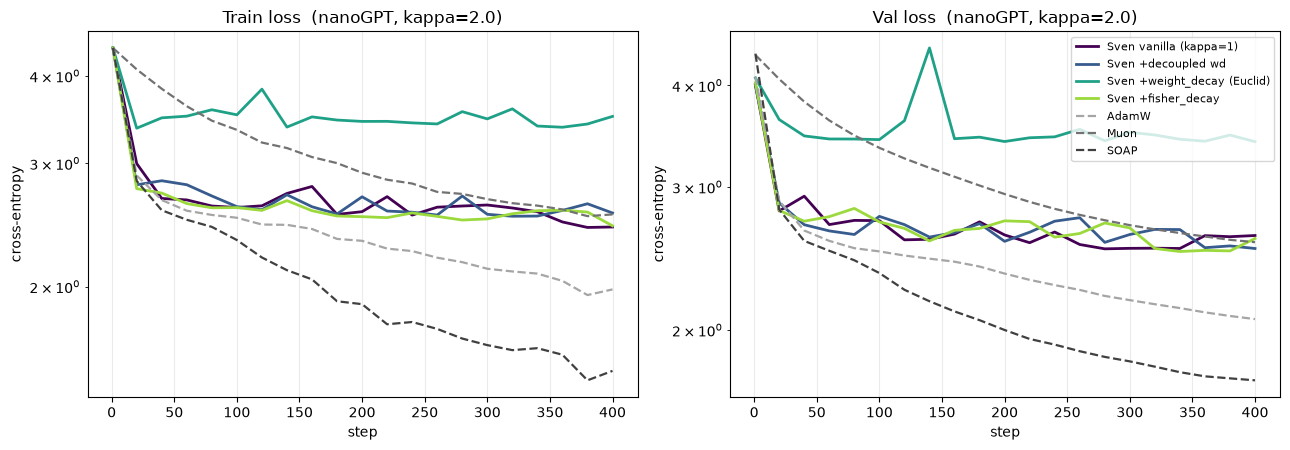

In [24]:
sven_names = list(SVEN_VARIANTS.keys())
base_names = list(BASELINE_LRS.keys())
cmap = plt.cm.viridis(np.linspace(0, 0.85, len(sven_names)))
gray = plt.cm.Greys(np.linspace(0.45, 0.8, len(base_names)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, key, title in zip(axes, ['train', 'val'], ['Train loss', 'Val loss']):
    for c, n in zip(cmap, sven_names):
        ax.plot(histories[n]['step'], histories[n][key], color=c, lw=2, label=n)
    for c, n in zip(gray, base_names):
        ax.plot(histories[n]['step'], histories[n][key], color=c, lw=1.6, ls='--', label=n)
    ax.set_title(f'{title}  (nanoGPT, kappa={KAPPA})'); ax.set_xlabel('step')
    ax.set_ylabel('cross-entropy'); ax.grid(alpha=0.25)
    ax.set_yscale('log')
axes[1].legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

## Summary — final validation loss / perplexity

In [ ]:
rows = sorted(((n, h['val'][-1], math.exp(h['val'][-1])) for n, h in histories.items()),
              key=lambda r: r[1])
print(f'{"optimizer":32s}{"val loss":>10s}{"val ppl":>10s}')
print('-'*52)
for n, v, ppl in rows:
    print(f'{n:32s}{v:10.4f}{ppl:10.2f}')

## Explore one setting by hand

Tweak the knobs and re-run just this cell to probe a single regularized variant
(e.g. sweep `weight_decay`, mix Euclidean + Fisher, add `damping`).

In [ ]:
one = train_sven({'weight_decay': 0.3, 'fisher_decay': 0.0, 'damping': 0.0})
plt.figure(figsize=(6.5, 4.3))
plt.plot(one['step'], one['train'], label='train', lw=2)
plt.plot(one['step'], one['val'], label='val', lw=2)
plt.title('single variant'); plt.xlabel('step'); plt.ylabel('CE'); plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()
print('final val:', round(one['val'][-1], 4), '| ppl:', round(math.exp(one['val'][-1]), 2))